# SMOTENC experiment

Use the same pre-call data and split as the baseline. Generate synthetic subscriber rows with SMOTENC, which keeps categorical features as categories during sampling. Validation and test data retain their natural class balance.


In [1]:
from scripts.uci_preprocessing_smotenc import (
    load_and_preprocess_uci_smotenc,
    make_smotenc_model_pipeline,
)

N_SYNTHETIC = 5000  # Number of additional subscriber rows in the full training split.
data = load_and_preprocess_uci_smotenc(
    n_synthetic=N_SYNTHETIC, seed=42, train_size=0.6, val_size=0.2, test_size=0.2
)
(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    X_train_processed, X_val_processed, X_test_processed,
    preprocessor, feature_names,
) = data.base
X_train_smotenc, y_train_smotenc = data.X_train_smotenc, data.y_train_smotenc

print("Original training counts:", y_train.value_counts().sort_index().to_dict())
print("SMOTENC training counts:", y_train_smotenc.value_counts().sort_index().to_dict())
print("Synthetic minority rows:", len(y_train_smotenc) - len(y_train))
print("Validation/test counts (unchanged):", y_val.value_counts().sort_index().to_dict(), y_test.value_counts().sort_index().to_dict())


## Candidate models and evaluation

Compare eight classifiers using three stratified training folds. Each fold fits preprocessing on its training rows only; the SMOTENC notebook also resamples within each training fold. Report F1, accuracy, precision, recall, and PR-AUC. Precision, recall, F1, and accuracy use a 0.5 probability cutoff; PR-AUC summarizes ranking across cutoffs. Select the model with the highest PR-AUC on the separate validation split, then evaluate it once on the untouched test split.


In [2]:
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, auc, f1_score, precision_recall_curve,
    precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

SEED = 42
CV_FOLDS = 3
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

models = {
    "Logistic regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Decision tree": DecisionTreeClassifier(random_state=SEED),
    "Random forest": RandomForestClassifier(n_estimators=100, n_jobs=2, random_state=SEED),
    "Gradient boosting": GradientBoostingClassifier(random_state=SEED),
    "XGBoost": xgb.XGBClassifier(n_estimators=150, n_jobs=2, random_state=SEED),
    "LightGBM": lgb.LGBMClassifier(n_estimators=150, verbosity=-1, n_jobs=2, random_state=SEED),
    "CatBoost": CatBoostClassifier(
        iterations=200, thread_count=2, verbose=0, random_seed=SEED,
        allow_writing_files=False,
    ),
}
models["Stacking ensemble"] = StackingClassifier(
    estimators=[
        ("logistic", make_smotenc_model_pipeline(
            models["Logistic regression"], preprocessor, X_train, data.smotenc_ratio, SEED,
        )),
        ("forest", make_smotenc_model_pipeline(
            models["Random forest"], preprocessor, X_train, data.smotenc_ratio, SEED,
        )),
        ("lightgbm", make_smotenc_model_pipeline(
            models["LightGBM"], preprocessor, X_train, data.smotenc_ratio, SEED,
        )),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    stack_method="predict_proba", cv=3, n_jobs=1,
)

def pr_auc_score(y_true, probabilities):
    precision, recall, _ = precision_recall_curve(y_true, probabilities)
    return auc(recall, precision)

def metric_row(y_true, probabilities):
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "f1": f1_score(y_true, predictions, zero_division=0),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "pr_auc": pr_auc_score(y_true, probabilities),
    }

def pr_auc_scorer(estimator, X, y_true):
    return pr_auc_score(y_true, estimator.predict_proba(X)[:, 1])

scoring = {
    "f1": "f1", "accuracy": "accuracy", "precision": "precision",
    "recall": "recall", "pr_auc": pr_auc_scorer,
}
cv_rows = []
validation_rows = []
fitted_models = {}
for name, estimator in models.items():
    pipeline = (
        clone(estimator) if name == "Stacking ensemble" else
        make_smotenc_model_pipeline(estimator, preprocessor, X_train, data.smotenc_ratio, SEED)
    )
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "model": name,
        **{f"{metric}_mean": scores[f"test_{metric}"].mean() for metric in scoring},
        **{f"{metric}_sd": scores[f"test_{metric}"].std(ddof=1) for metric in scoring},
    })
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    validation_rows.append({"model": name, **metric_row(y_val, pipeline.predict_proba(X_val)[:, 1])})
    print(f"Finished {name}")

cv_results = pd.DataFrame(cv_rows).set_index("model").sort_values("pr_auc_mean", ascending=False)
validation_results = pd.DataFrame(validation_rows).set_index("model").sort_values("pr_auc", ascending=False)
print("\nThree-fold cross-validation (training split; mean ± SD):")
display(cv_results.round(4))
print("\nHeld-out validation metrics:")
display(validation_results.round(4))


                     f1_mean  accuracy_mean  precision_mean  recall_mean  pr_auc_mean   f1_sd  accuracy_sd  precision_sd  recall_sd  pr_auc_sd
model                                                                                                                                         
CatBoost              0.3706         0.8919          0.5808       0.2723       0.4228  0.0113       0.0004        0.0066     0.0133     0.0097
Stacking ensemble     0.3108         0.8915          0.6048       0.2093       0.4199  0.0205       0.0023        0.0288     0.0166     0.0124
LightGBM              0.3750         0.8895          0.5543       0.2836       0.4123  0.0118       0.0008        0.0102     0.0159     0.0045
Gradient boosting     0.3478         0.8886          0.5513       0.2540       0.4087  0.0018       0.0002        0.0030     0.0019     0.0097
XGBoost               0.3740         0.8861          0.5242       0.2909       0.3794  0.0123       0.0023        0.0191     0.0125     0.0081

                         f1  accuracy  precision  recall  pr_auc
model                                                           
Stacking ensemble    0.3417    0.8952     0.6440  0.2325  0.4509
CatBoost             0.3752    0.8939     0.6038  0.2722  0.4475
LightGBM             0.3967    0.8944     0.5981  0.2968  0.4403
Gradient boosting    0.3499    0.8932     0.6075  0.2457  0.4241
Random forest        0.3825    0.8861     0.5230  0.3015  0.4196
XGBoost              0.3958    0.8923     0.5758  0.3015  0.4173
Logistic regression  0.4078    0.8895     0.5469  0.3251  0.3946
Decision tree        0.3076    0.8227     0.2832  0.3365  0.3487

## Selected model: held-out test evaluation

Select by validation PR-AUC. The test split stays untouched until this final evaluation.


In [3]:
best_model_name = validation_results.index[0]
best_model = fitted_models[best_model_name]
test_results = pd.DataFrame(
    [metric_row(y_test, best_model.predict_proba(X_test)[:, 1])],
    index=[best_model_name],
)
print("Selected model:", best_model_name)
print("Held-out test metrics:")
display(test_results.round(4))


                       f1  accuracy  precision  recall  pr_auc
Stacking ensemble  0.3768     0.899     0.6781  0.2609  0.4818

## Results at a glance

The first chart compares PR-AUC across models; the second shows validation precision and recall at the 0.5 cutoff.


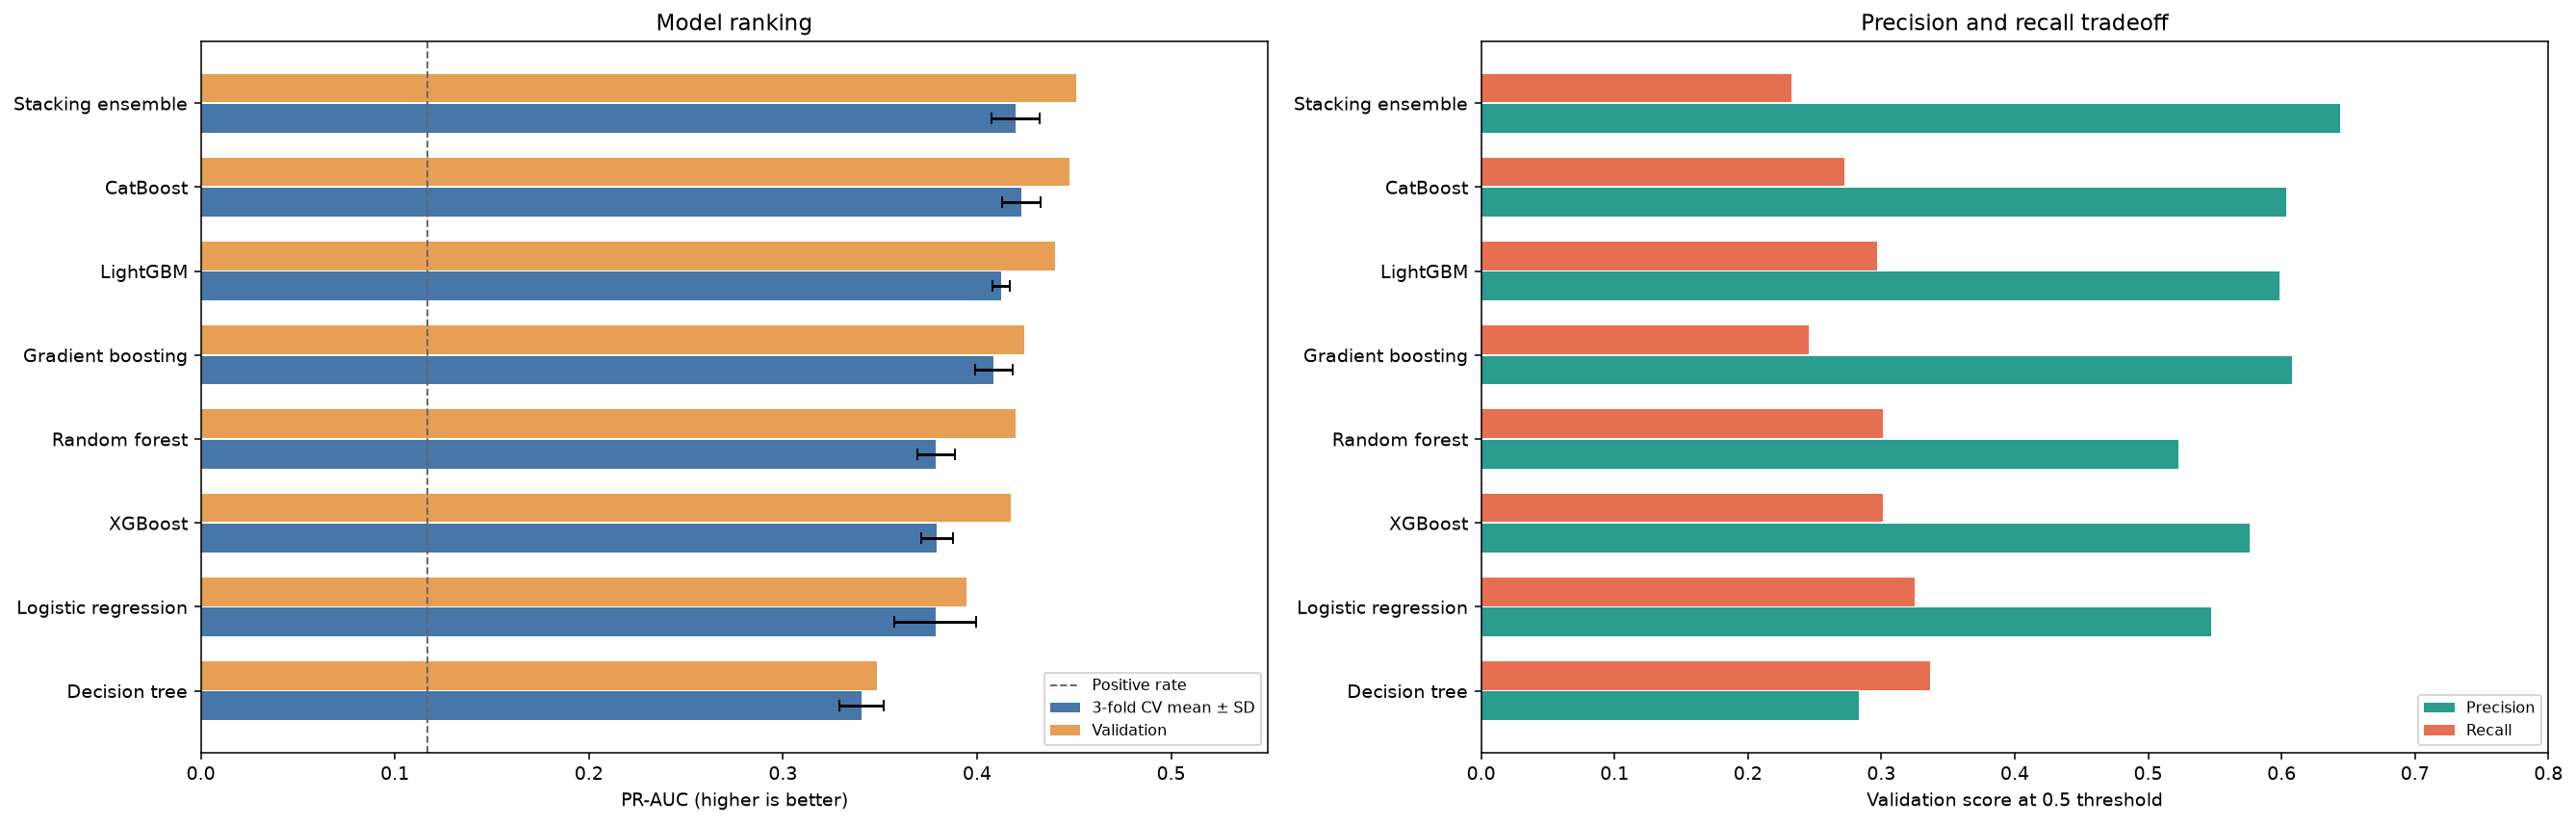

In [4]:
import matplotlib.pyplot as plt
import numpy as np

order = validation_results.index[::-1]
positions = np.arange(len(order))
fig, axes = plt.subplots(1, 2, figsize=(19, 6), layout="constrained")

# PR-AUC is the primary ranking metric for this imbalanced target.
axes[0].barh(positions - 0.18, cv_results.loc[order, "pr_auc_mean"],
             height=0.34, xerr=cv_results.loc[order, "pr_auc_sd"],
             capsize=3, label="3-fold CV mean ± SD", color="#4776A8")
axes[0].barh(positions + 0.18, validation_results.loc[order, "pr_auc"],
             height=0.34, label="Validation", color="#E69F54")
axes[0].axvline(y_train.mean(), color="#666666", linestyle="--", linewidth=1,
                label="Positive rate")
axes[0].set_yticks(positions, order)
axes[0].set_xlim(0, 0.55)
axes[0].set_xlabel("PR-AUC (higher is better)")
axes[0].set_title("Model ranking")
axes[0].legend(fontsize=8, loc="lower right")

axes[1].barh(positions - 0.18, validation_results.loc[order, "precision"],
             height=0.34, label="Precision", color="#2A9D8F")
axes[1].barh(positions + 0.18, validation_results.loc[order, "recall"],
             height=0.34, label="Recall", color="#E76F51")
axes[1].set_yticks(positions, order)
axes[1].set_xlim(0, 0.8)
axes[1].set_xlabel("Validation score at 0.5 threshold")
axes[1].set_title("Precision and recall tradeoff")
axes[1].legend(fontsize=8, loc="lower right")

plt.show()


## Interpretation

**Model selection.** Stacking ensemble had the highest validation PR-AUC (0.4509). The validation table compares all eight models on the same untouched split.

**Held-out test.** The selected model achieved F1 0.3768, accuracy 0.8990, precision 0.6781, recall 0.2609, and PR-AUC 0.4818. F1, accuracy, precision, and recall use a 0.5 probability cutoff; PR-AUC summarizes ranking across cutoffs.
